In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.storagelevel import StorageLevel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

ĐOC DỮ LIỆU TỪ HDFS

In [2]:
spark = (
    SparkSession.builder
    #.master("spark://100.77.205.48:7077")
    .appName("NYC Taxi Data Query")
    #.config("spark.executor.memory", "1g")
    #.config("spark.driver.memory", "1g")
    .getOrCreate()
)

#print(spark.sparkContext.master)

spark://100.77.205.48:7077


In [3]:
spark.sparkContext.setLogLevel("WARN")

df = spark.read.parquet(
     #"hdfs://master:9000/output/yellow_taxi_cleaned"
     "hdfs://localhost:9000/output/yellow_taxi_cleaned"
 )

df.createOrReplaceTempView("yellow_taxi")

# Cache trong RAM
df.cache()

# Kích hoạt cache
print(f"Total records: {df.count():,}")


Total records: 3,502,694


QUERY 1: Khung giờ mang lại doanh thu cao nhất trong ngày

In [4]:
query1_df = spark.sql("""
WITH hourly_revenue AS
(
    SELECT
        pickup_hour,
        COUNT(*) AS Tong_so_chuyen,
        ROUND(SUM(total_amount),2) AS Doanh_thu
    FROM yellow_taxi
    GROUP BY pickup_hour
)
SELECT
    pickup_hour,
    Tong_so_chuyen,
    Doanh_thu,
    ROUND(
        Doanh_thu/SUM(Doanh_thu) OVER() *100,2) AS Phan_tram_doanh_thu,
    RANK() OVER(
        ORDER BY Doanh_thu DESC
    ) AS Xep_hang_doanh_thu
FROM hourly_revenue
ORDER BY pickup_hour
""")
query1_df.show()

+-----------+--------------+----------+-------------------+------------------+
|pickup_hour|Tong_so_chuyen| Doanh_thu|Phan_tram_doanh_thu|Xep_hang_doanh_thu|
+-----------+--------------+----------+-------------------+------------------+
|          0|        108107|3263279.56|               3.14|                18|
|          1|         74963|2201951.34|               2.12|                19|
|          2|         52001|1448813.66|               1.39|                21|
|          3|         37152|1053441.31|               1.01|                23|
|          4|         27494| 872286.62|               0.84|                24|
|          5|         31701|1101999.87|               1.06|                22|
|          6|         61576|2047829.69|               1.97|                20|
|          7|        109606|3450294.44|               3.32|                17|
|          8|        142943|4318786.86|               4.15|                15|
|          9|        150885|4289321.37|             

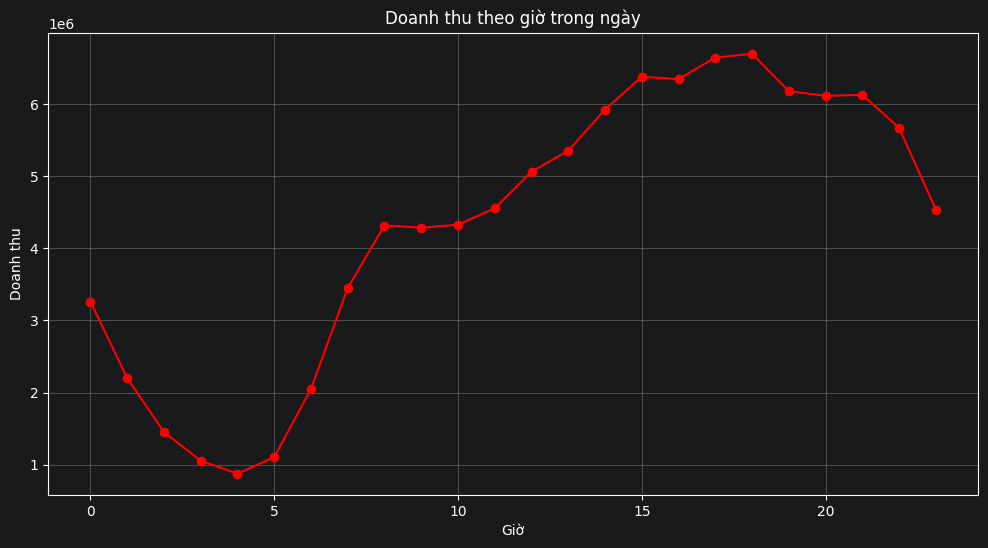

In [5]:
pdf = query1_df.toPandas()
plt.figure(figsize=(12,6))

plt.plot(
    pdf["pickup_hour"],
    pdf["Doanh_thu"],
    marker="o",
    color ="red")

plt.title("Doanh thu theo giờ trong ngày")

plt.xlabel("Giờ")
plt.ylabel("Doanh thu")

plt.grid(True)
plt.show()

QUERY 2: Giờ cao điểm nào có hiệu quả nhất?

In [6]:
query2_df = spark.sql("""
SELECT
    pickup_hour,
    COUNT(*) AS Tong_so_chuyen,
    ROUND(
        SUM(total_amount),2) AS Doanh_thu,
    ROUND(
        SUM(total_amount)/COUNT(*),2) AS Doanh_thu_tren_chuyen
FROM yellow_taxi
GROUP BY pickup_hour
""")
query2_df.show()

+-----------+--------------+----------+---------------------+
|pickup_hour|Tong_so_chuyen| Doanh_thu|Doanh_thu_tren_chuyen|
+-----------+--------------+----------+---------------------+
|         12|        179963|5065190.75|                28.15|
|         22|        188560|5674594.28|                30.09|
|          1|         74963|2201951.34|                29.37|
|         13|        187592|5356383.94|                28.55|
|          6|         61576|2047829.69|                33.26|
|         16|        202614|6351214.43|                31.35|
|          3|         37152|1053441.31|                28.35|
|         20|        205773|6119502.43|                29.74|
|          5|         31701|1101999.87|                34.76|
|         19|        208256|6183267.96|                29.69|
|         15|        212528|6384710.96|                30.04|
|         17|        220132|6649951.22|                30.21|
|          9|        150885|4289321.37|                28.43|
|       

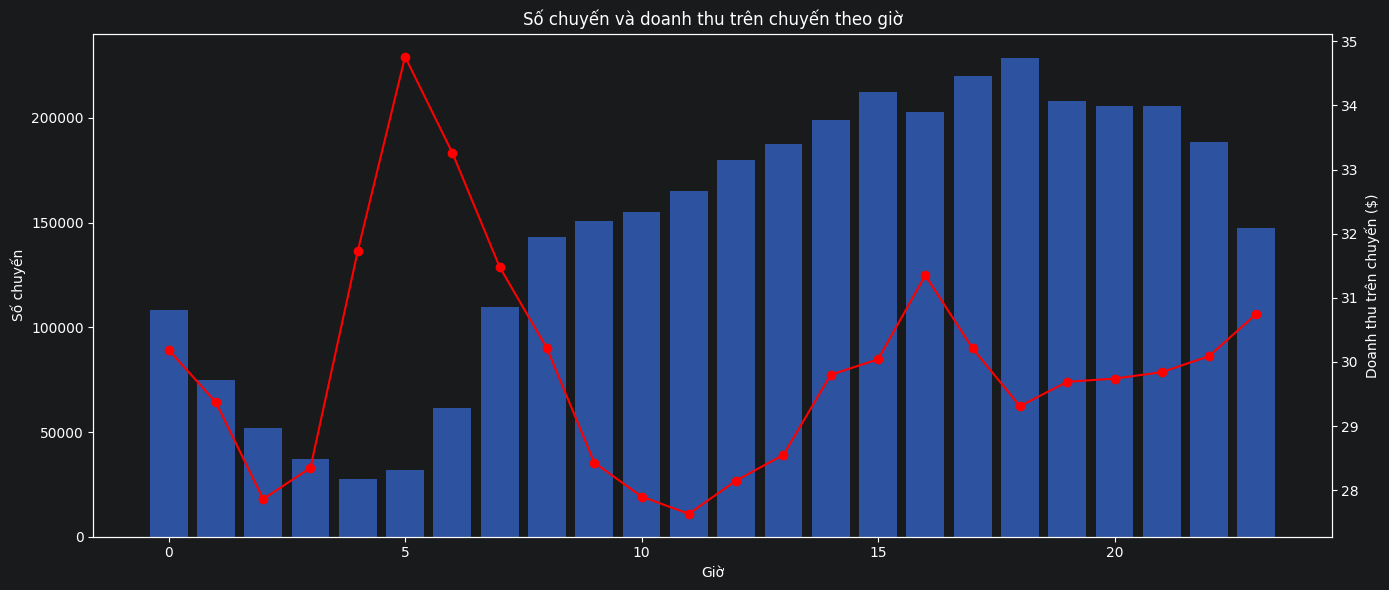

In [7]:
pdf = query2_df.toPandas()
pdf = pdf.sort_values("pickup_hour")
fig, ax1 = plt.subplots(figsize=(14,6))
# Cột: số chuyến
ax1.bar(
    pdf["pickup_hour"],
    pdf["Tong_so_chuyen"],
    alpha=0.7)

ax1.set_xlabel("Giờ")
ax1.set_ylabel("Số chuyến")

# Đường: doanh thu/chuyến
ax2 = ax1.twinx()

ax2.plot(
    pdf["pickup_hour"],
    pdf["Doanh_thu_tren_chuyen"],
    marker="o",
    color="red")

ax2.set_ylabel("Doanh thu trên chuyến ($)")

plt.title("Số chuyến và doanh thu trên chuyến theo giờ")

plt.tight_layout()
plt.show()

In [27]:
spark.stop()